In [ ]:
pip install torch torchvision matplotlib opencv-python

In [ ]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

!tar -xvzf images.tar.gz
!tar -xvzf annotations.tar.gz

Streaming output truncated to the last 5000 lines.
annotations/trimaps/._pomeranian_180.png
annotations/trimaps/pomeranian_180.png
annotations/trimaps/._pomeranian_181.png
annotations/trimaps/pomeranian_181.png
annotations/trimaps/._pomeranian_182.png
annotations/trimaps/pomeranian_182.png
annotations/trimaps/._pomeranian_183.png
annotations/trimaps/pomeranian_183.png
annotations/trimaps/._pomeranian_184.png
annotations/trimaps/pomeranian_184.png
annotations/trimaps/._pomeranian_185.png
annotations/trimaps/pomeranian_185.png
annotations/trimaps/._pomeranian_186.png
annotations/trimaps/pomeranian_186.png
annotations/trimaps/._pomeranian_187.png
annotations/trimaps/pomeranian_187.png
annotations/trimaps/._pomeranian_188.png
annotations/trimaps/pomeranian_188.png
annotations/trimaps/._pomeranian_189.png
annotations/trimaps/pomeranian_189.png
annotations/trimaps/._pomeranian_19.png
annotations/trimaps/pomeranian_19.png
annotations/trimaps/._pomeranian_190.png
annotations/trimaps/pomeranian

1. Imports


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

2. Dataset Class (for extracted dataset)

In [ ]:
class PetDataset(Dataset):
    def __init__(self, root_dir):
        self.image_dir = os.path.join(root_dir, "images")
        self.mask_dir = os.path.join(root_dir, "annotations/trimaps")

        # Filter out non-jpg files (like macOS resource fork files '._*')
        self.images = [img for img in os.listdir(self.image_dir) if img.endswith('.jpg')]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        # Ensure mask path corresponds to a .png file
        mask_name = img_name.replace(".jpg", ".png")
        mask_path = os.path.join(self.mask_dir, mask_name)

        # Read image
        image = cv2.imread(img_path)
        if image is None:  # Check if image was loaded successfully
            raise FileNotFoundError(f"Image not found or corrupted: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read mask
        mask = cv2.imread(mask_path, 0)
        if mask is None:  # Check if mask was loaded successfully
            raise FileNotFoundError(f"Mask not found or corrupted: {mask_path}")

        # Resize
        image = cv2.resize(image, (128, 128))
        mask = cv2.resize(mask, (128, 128))

        # Normalize
        image = image / 255.0

        # Convert mask to binary (pet vs background)
        mask = (mask == 1).astype("float32")

        # Convert to tensor
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask

3. Load Dataset

In [ ]:
dataset = PetDataset("/content")

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=4, shuffle=True)
test_loader = DataLoader(test_data, batch_size=4)

4. U-Net Model


In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU()
            )

        self.enc1 = block(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = block(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = block(128, 256)

        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec1 = block(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = block(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        d1 = self.up1(e3)
        d1 = torch.cat([d1, e2], dim=1)
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([d2, e1], dim=1)
        d2 = self.dec2(d2)

        return torch.sigmoid(self.final(d2))

5. IoU Function

In [ ]:
def iou_score(pred, target):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return intersection / union

6. Training Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

7. Training Loop

In [ ]:
for epoch in range(5):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 750.8948
Epoch 2, Loss: 648.6518
Epoch 3, Loss: 555.5994
Epoch 4, Loss: 478.5721
Epoch 5, Loss: 439.6328


8. Evaluation (IoU + Accuracy)

In [ ]:
model.eval()
total_iou = 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        total_iou += iou_score(preds, masks).item()

print("Average IoU:", total_iou / len(test_loader))

Average IoU: 0.5851716469268541


9. Visualization

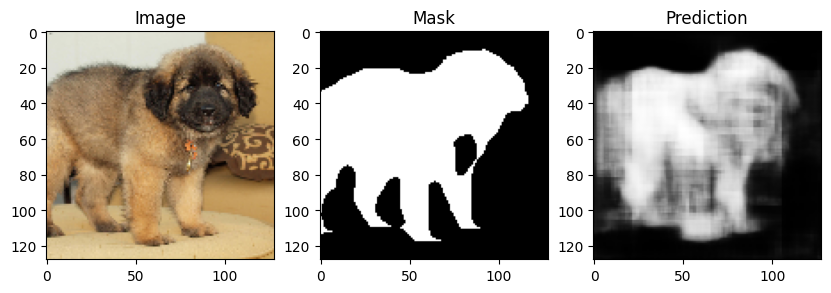

In [ ]:
img, mask = dataset[0]

model.eval()
with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))[0][0].cpu()

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(mask[0], cmap='gray')

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred, cmap='gray')

plt.show()